In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import timm

In [9]:
candidates = [
    Path('train_data'),
    Path('../train_data'),
    Path.cwd() / 'train_data',
    Path.cwd().parent / 'train_data',
]
train_data_dir = next((p.resolve() for p in candidates if p.exists()), None)
if train_data_dir is None:
    raise FileNotFoundError(
        "Could not find 'train_data' folder. Tried: " + ", ".join(str(p) for p in candidates)
    )
print('Using train_data:', train_data_dir)

seed = 42
TRAIN_FRAC = 0.90  # 90 % train, 10 % validation

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(train_data_dir), transform=transform)
num_classes = len(dataset.classes)
print('Num classes:', num_classes)

# Deterministic 90 / 10 split
n_all   = len(dataset)
k_train = int(round(TRAIN_FRAC * n_all))
k_test  = n_all - k_train

g = torch.Generator().manual_seed(seed)
perm      = torch.randperm(n_all, generator=g)
train_idx = perm[:k_train].tolist()
test_idx  = perm[k_train:].tolist()

train_img = Subset(dataset, train_idx)  # 90 %
test_img  = Subset(dataset, test_idx)   # 10 %

batch_size  = 32
num_workers = 4  # safer default on macOS / Colab

g_loader = torch.Generator().manual_seed(seed)
train_loader = DataLoader(
    train_img,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    generator=g_loader,
)
test_loader = DataLoader(
    test_img,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print('Total images:', n_all)
print(f'Train images: {len(train_img)} ({TRAIN_FRAC:.0%})')
print(f'Test  images: {len(test_img)}  ({1-TRAIN_FRAC:.0%})')
print('Classes (folder order):')
for i, name in enumerate(dataset.classes):
    print(f'  {i}: {name}')


Using train_data: /content/train_data
Num classes: 30
Total images: 6993
Train images: 6294 (90%)
Test  images: 699  (10%)
Classes (folder order):
  0: Airport
  1: BareLand
  2: BaseballField
  3: Beach
  4: Bridge
  5: Center
  6: Church
  7: Commercial
  8: DenseResidential
  9: Desert
  10: Farmland
  11: Forest
  12: Industrial
  13: Meadow
  14: MediumResidential
  15: Mountain
  16: Park
  17: Parking
  18: Playground
  19: Pond
  20: Port
  21: RailwayStation
  22: Resort
  23: River
  24: School
  25: SparseResidential
  26: Square
  27: Stadium
  28: StorageTanks
  29: Viaduct


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
# --- Frozen feature extractor (backbone) + new linear classifier ---
model_name = 'densenet121'
device = (
    'cuda' if torch.cuda.is_available() else
    'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else
    'cpu'
)
print('Device:', device)

# 1) Load pretrained backbone
model = timm.create_model(model_name, pretrained=True)

# 2) Replace final classification layer for our dataset
model.reset_classifier(num_classes)  # new linear layer
classifier = model.get_classifier()
print('Classifier:', classifier)

# 3) Freeze ALL params, then unfreeze ONLY classifier params
for p in model.parameters():
    p.requires_grad = False
for p in classifier.parameters():
    p.requires_grad = True

trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print('Trainable parameters:', trainable)
assert all(n.startswith(('fc', 'classifier', 'head')) for n in trainable), 'Non-classifier params are trainable!'

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)


Device: cuda


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Classifier: Linear(in_features=1024, out_features=30, bias=True)
Trainable parameters: ['classifier.weight', 'classifier.bias']


In [11]:
epochs = 20

# History for plots
train_loss_hist, train_acc_hist = [], []
val_loss_hist, val_acc_hist = [], []

for epoch in range(1, epochs + 1):
    # Keep feature extractor strictly frozen (BatchNorm stats won't update)
    model.eval()

    train_loss_sum = torch.zeros((), device=device)
    train_correct = torch.zeros((), device=device)
    train_seen = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        train_loss_sum += loss.detach() * bs
        train_correct += (logits.argmax(dim=1) == y).detach().sum()
        train_seen += bs

    train_loss = (train_loss_sum / max(1, train_seen)).item()
    train_acc = (train_correct / max(1, train_seen)).item()

    val_loss_sum = torch.zeros((), device=device)
    val_correct = torch.zeros((), device=device)
    val_seen = 0

    with torch.inference_mode():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            bs = x.size(0)
            val_loss_sum += loss * bs
            val_correct += (logits.argmax(dim=1) == y).sum()
            val_seen += bs

    val_loss = (val_loss_sum / max(1, val_seen)).item()
    val_acc = (val_correct / max(1, val_seen)).item()

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f'Epoch {epoch}/{epochs} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/20 | train loss 1.1187 acc 0.7316 | val loss 0.5312 acc 0.8670
Epoch 2/20 | train loss 0.3938 acc 0.9059 | val loss 0.4029 acc 0.8927
Epoch 3/20 | train loss 0.2670 acc 0.9379 | val loss 0.3551 acc 0.8941
Epoch 4/20 | train loss 0.2009 acc 0.9569 | val loss 0.3183 acc 0.9013
Epoch 5/20 | train loss 0.1599 acc 0.9684 | val loss 0.3111 acc 0.9113
Epoch 6/20 | train loss 0.1272 acc 0.9784 | val loss 0.2876 acc 0.9142
Epoch 7/20 | train loss 0.1041 acc 0.9838 | val loss 0.2738 acc 0.9185
Epoch 8/20 | train loss 0.0870 acc 0.9878 | val loss 0.2816 acc 0.9113
Epoch 9/20 | train loss 0.0750 acc 0.9900 | val loss 0.2647 acc 0.9142
Epoch 10/20 | train loss 0.0628 acc 0.9922 | val loss 0.2599 acc 0.9185
Epoch 11/20 | train loss 0.0542 acc 0.9936 | val loss 0.2630 acc 0.9185
Epoch 12/20 | train loss 0.0464 acc 0.9963 | val loss 0.2633 acc 0.9142
Epoch 13/20 | train loss 0.0414 acc 0.9971 | val loss 0.2579 acc 0.9199
Epoch 14/20 | train loss 0.0360 acc 0.9979 | val loss 0.2538 acc 0.9199
E

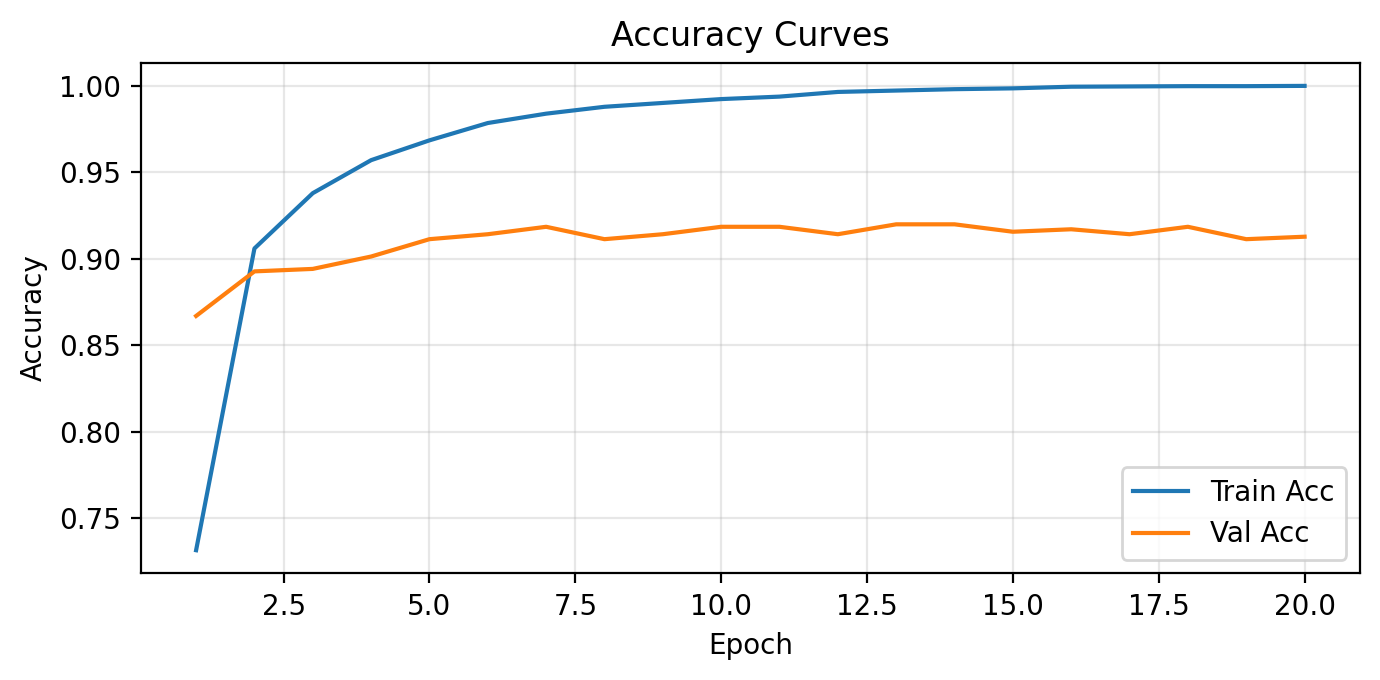

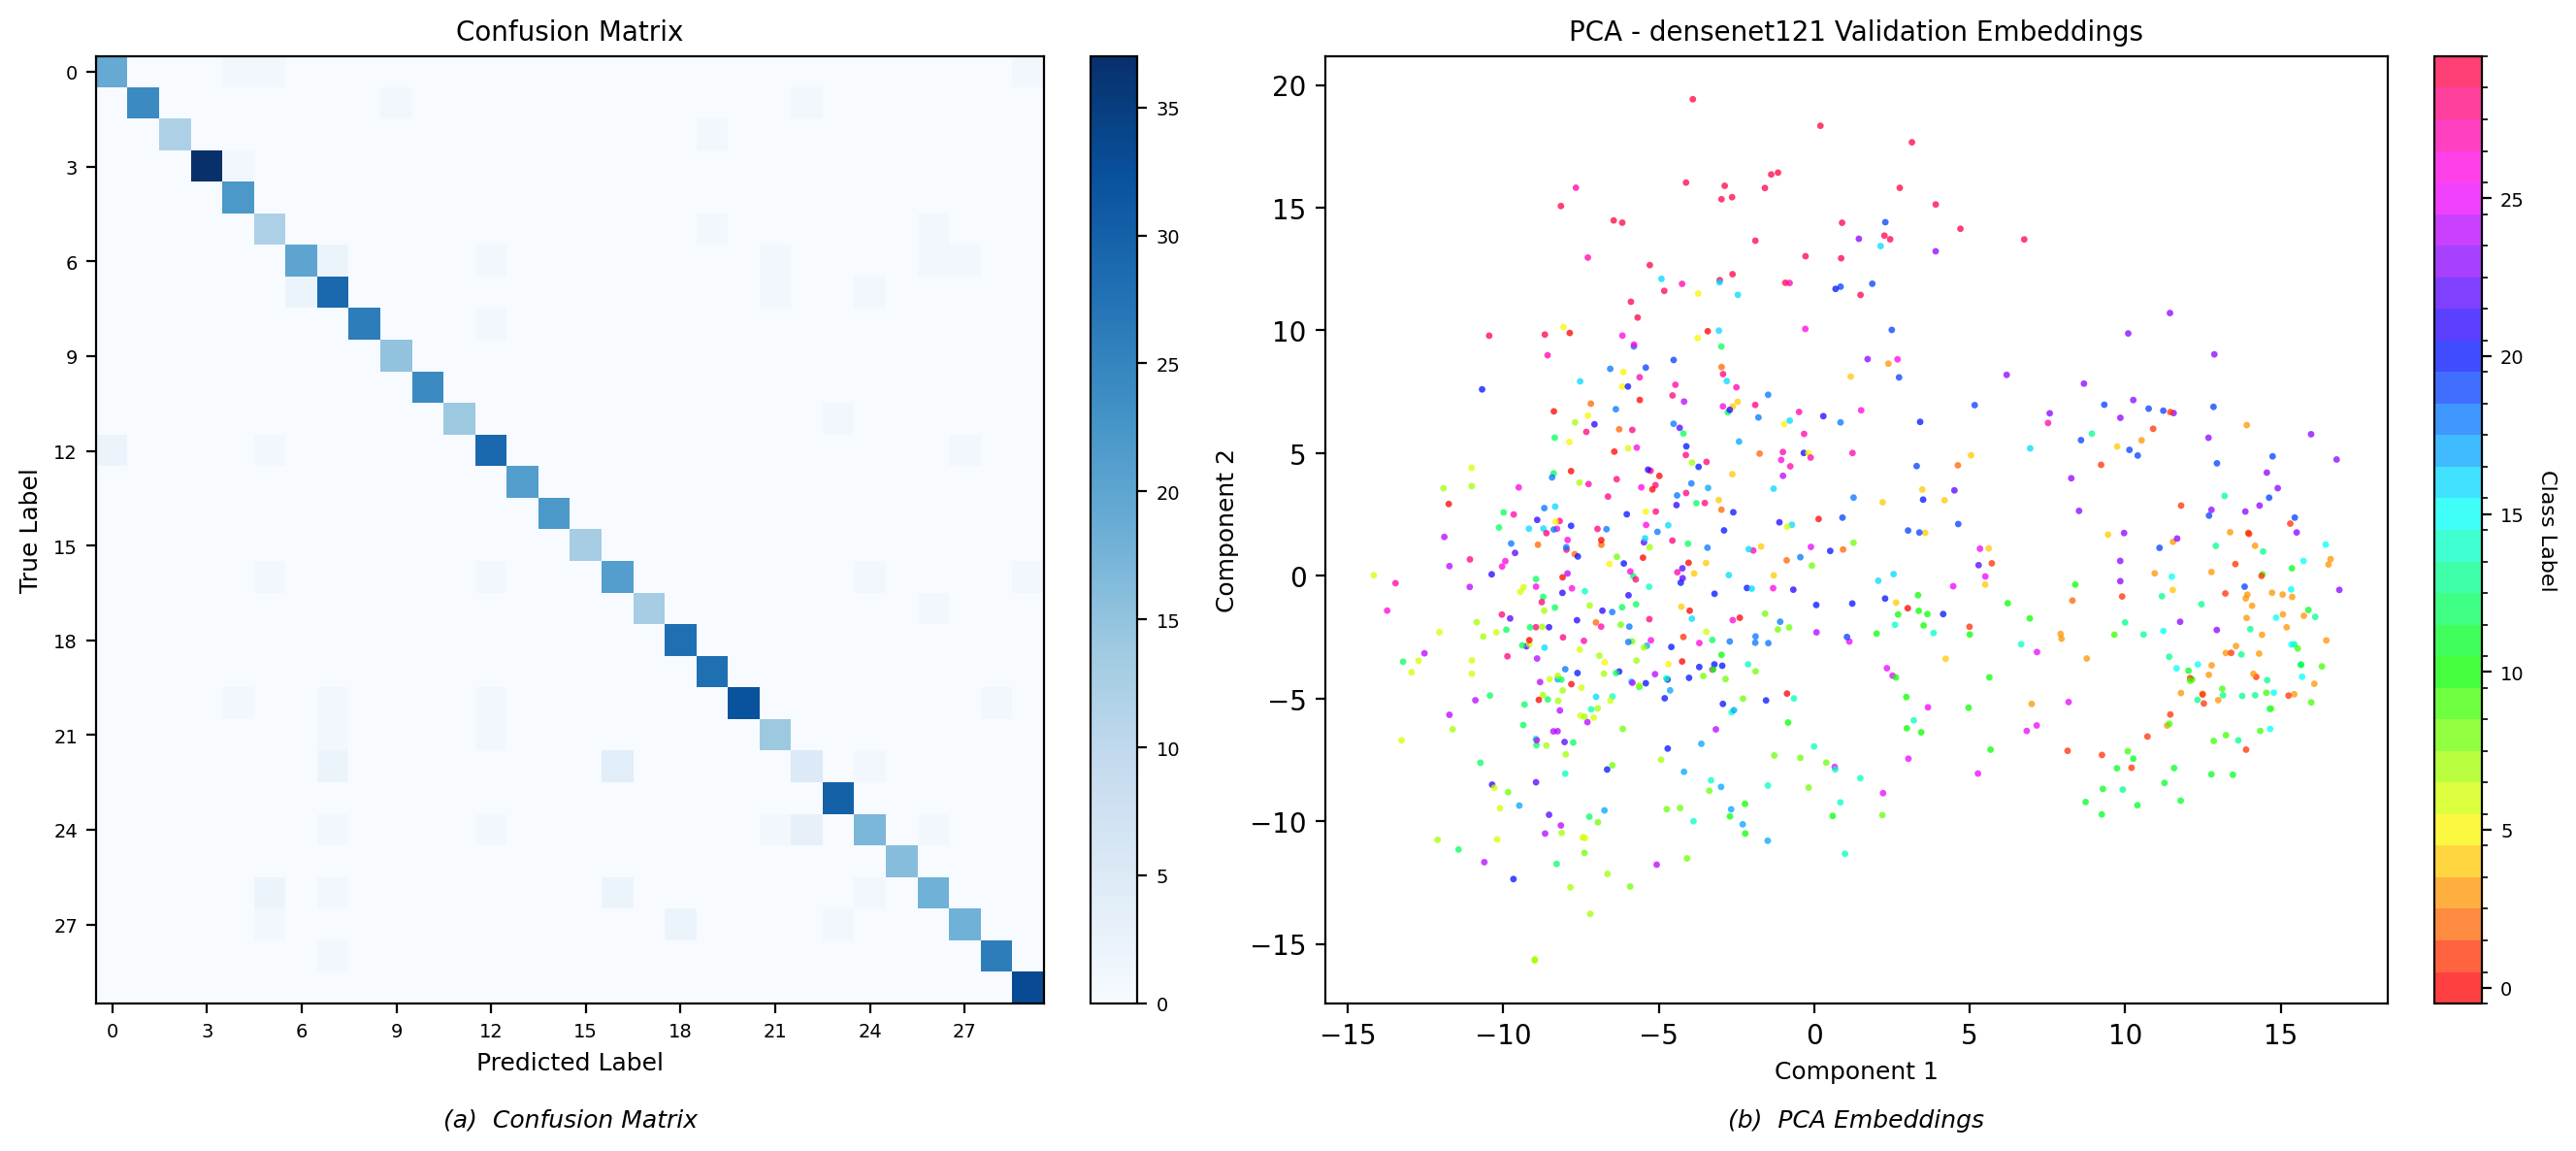

Saved confusion_pca.png


In [12]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

DPI = 200

# ── 1. Accuracy curves ────────────────────────────────────────────────────
epochs_axis = list(range(1, len(train_acc_hist) + 1))
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=DPI)
ax.plot(epochs_axis, train_acc_hist, label='Train Acc')
ax.plot(epochs_axis, val_acc_hist,   label='Val Acc')
ax.set_xlabel('Epoch');  ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Curves');  ax.grid(True, alpha=0.3);  ax.legend()
fig.tight_layout()
plt.show()

# ── 2 & 3. Side-by-side: Confusion Matrix | PCA Embeddings ───────────────
# 2a. Build confusion matrix
conf = torch.zeros((num_classes, num_classes), dtype=torch.int64)
model.eval()
with torch.inference_mode():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        idx   = (y * num_classes + preds).to('cpu')
        conf += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

# 2b. PCA embeddings
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
for p in feature_model.parameters(): p.requires_grad = False
feature_model.eval().to(device)

max_embed_samples = 2000
emb_list, lab_list, seen = [], [], 0
with torch.inference_mode():
    for x, y in test_loader:
        feats = feature_model(x.to(device))
        emb_list.append(feats.cpu());  lab_list.append(y.cpu())
        seen += x.size(0)
        if seen >= max_embed_samples: break

emb = torch.cat(emb_list, dim=0)[:max_embed_samples].float()
lab = torch.cat(lab_list, dim=0)[:max_embed_samples].long()
emb = emb - emb.mean(dim=0, keepdim=True)
_, _, V = torch.pca_lowrank(emb, q=2)
xy     = (emb @ V[:, :2]).numpy()
lab_np = lab.numpy()

# ── Shared colour setup (matches the reference sidebar) ──────────────────
N_CLS = num_classes
cmap  = plt.colormaps['tab20'].resampled(N_CLS) if N_CLS <= 20 else \
        ListedColormap(plt.colormaps['hsv'](np.linspace(0, 1, N_CLS, endpoint=False)))
bounds = np.arange(-0.5, N_CLS + 0.5, 1)
norm   = BoundaryNorm(bounds, cmap.N)

# ── Figure layout ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=DPI)

# (a) Confusion Matrix
ax = axes[0]
cm_arr = conf.numpy().astype(float)
im = ax.imshow(cm_arr, interpolation='nearest', cmap='Blues')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=7)
tick_step = max(1, N_CLS // 10)
tick_locs = np.arange(0, N_CLS, tick_step)
ax.set_xticks(tick_locs);  ax.set_xticklabels(tick_locs, fontsize=7)
ax.set_yticks(tick_locs);  ax.set_yticklabels(tick_locs, fontsize=7)
ax.set_xlabel('Predicted Label', fontsize=9)
ax.set_ylabel('True Label', fontsize=9)
ax.set_title('Confusion Matrix', fontsize=10)

# (b) PCA Embeddings
ax = axes[1]
sc = ax.scatter(xy[:, 0], xy[:, 1],
                c=lab_np, cmap=cmap, norm=norm,
                s=6, alpha=0.75, linewidths=0)
cbar2 = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
# Tick marks at every 5th class, matching the reference sidebar
cb_ticks = np.arange(0, N_CLS, 5)
cbar2.set_ticks(cb_ticks)
cbar2.set_ticklabels([str(t) for t in cb_ticks])
cbar2.ax.tick_params(labelsize=7)
cbar2.set_label('Class Label', fontsize=8, rotation=270, labelpad=12)
ax.set_xlabel('Component 1', fontsize=9)
ax.set_ylabel('Component 2', fontsize=9)
ax.set_title(f'PCA - {model_name} Validation Embeddings', fontsize=10)

# Sub-figure labels
for ax, lbl in zip(axes, ['(a)  Confusion Matrix', '(b)  PCA Embeddings']):
    ax.set_xlabel(ax.get_xlabel())   # keep existing label
    ax.annotate(lbl, xy=(0.5, -0.13), xycoords='axes fraction',
                ha='center', fontsize=9, style='italic')

fig.tight_layout()
plt.savefig('confusion_pca.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved confusion_pca.png')
